# 04 · Tuning, ablation, sensitivity and stress tests (Phase 8)

All results are produced by `scripts/phase8_experiments.py` and read here from `reports/phase8/`. They are
cross-validated **model predictions** on held-out FLEX tests (same 25 grouped splits as Phase 7), not experimental
results.

**Pre-registered selection rule** (fixed before this phase ran): the final model has the lowest mean log loss over
the 25 outer folds; a simpler model within one standard error of the best is preferred.

**Design change during this phase:** pressure was dropped from the final model (decision D-001,
`docs/decisions.md`) after the stress tests in section 4. Sections 1–4 use the original design; section 5 applies the
unchanged selection rule to the final, pressure-free candidates.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import display
from flameguard import eda, plots

eda.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
R = ROOT / "reports" / "phase8"
cols = ["model", "log_loss_mean", "log_loss_se", "brier_mean", "roc_auc_mean", "pr_auc_mean",
        "recall@safe", "precision@safe", "within_1se_of_best", "selected"]

## 1. Hyperparameter tuning (nested grouped CV, original design)

Each outer training fold runs its own grid search over grouped inner folds, optimising log loss. The outer test fold
is never used for tuning.

In [2]:
display(pd.read_csv(R / "model_selection.csv")[cols].round(4))
tuned = pd.read_csv(R / "tuning_fold_metrics.csv")
tuned.groupby("model")["best_params"].value_counts().rename("outer folds").to_frame().head(12)

,model,log_loss_mean,log_loss_se,brier_mean,roc_auc_mean,pr_auc_mean,recall@safe,precision@safe,within_1se_of_best,selected
0,logreg,0.3457,0.0225,0.1086,0.9216,0.8678,0.8976,0.6371,True,True
1,logreg_tuned,0.3692,0.0257,0.1118,0.9208,0.8656,0.8862,0.6409,False,False
2,random_forest,0.4139,0.0168,0.1345,0.8783,0.8082,0.9088,0.5579,False,False
3,xgboost_tuned,0.4157,0.0214,0.1373,0.8836,0.8050,0.8950,0.5748,False,False
4,xgboost,0.4185,0.0229,0.1360,0.8862,0.8018,0.8750,0.5784,False,False
5,random_forest_tuned,0.4223,0.0178,0.1387,0.8695,0.7905,0.8996,0.5453,False,False
6,o2_only_logreg,0.4685,0.0204,0.1517,0.8210,0.6987,0.8956,0.4553,False,False


outer folds
model               best_params                                                    
logreg_tuned        {"model__C": 0.3}                                            14
                    {"model__C": 1.0}                                             6
                    {"model__C": 3.0}                                             5
random_forest_tuned {"model__max_features": "sqrt", "model__min_sam...           10
                    {"model__max_features": "sqrt", "model__min_sam...            6
                    {"model__max_features": 0.5, "model__min_sample...            6
                    {"model__max_features": 0.5, "model__min_sample...            2
                    {"model__max_features": "sqrt", "model__min_sam...            1
xgboost_tuned       {"model__learning_rate": 0.1, "model__max_depth...            7
                    {"model__learning_rate": 0.03, "model__max_dept...            3
                    {"model__learning_rate": 0.1, "model__max_depth...            3
                    {"model__learning_rate": 0.1, "model__max_depth...            2

**Read-out.** Tuning did not help any model family. Tuned logistic regression is slightly *worse* than the
fixed C = 1 version (log loss 0.369 vs 0.346): the chosen C changes from fold to fold (0.3, 1 or 3), and on ~200
training tests that extra selection step adds more variance than it removes bias. Tuned trees stay at
ROC-AUC ≈ 0.87–0.88, behind logistic regression. Under the original design the rule selects the untuned logistic
regression.

## 2. Feature ablation (logistic regression, original design, threshold-free metrics)

,roc_auc_mean,pr_auc_mean,brier_mean,log_loss_mean
model,,,,
full (base + fuel x d0),0.922,0.868,0.109,0.346
no fuel x d0 interaction,0.889,0.818,0.130,0.408
+ p_o2_atm,0.923,0.870,0.108,0.354
- pressure,0.925,0.877,0.103,0.336
- droplet size (and interaction),0.855,0.776,0.147,0.444
"- suppressant (CO2, He)",0.924,0.870,0.107,0.351
- fuel (and interaction),0.883,0.787,0.135,0.426
O2 + fuel only,0.861,0.742,0.145,0.436


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


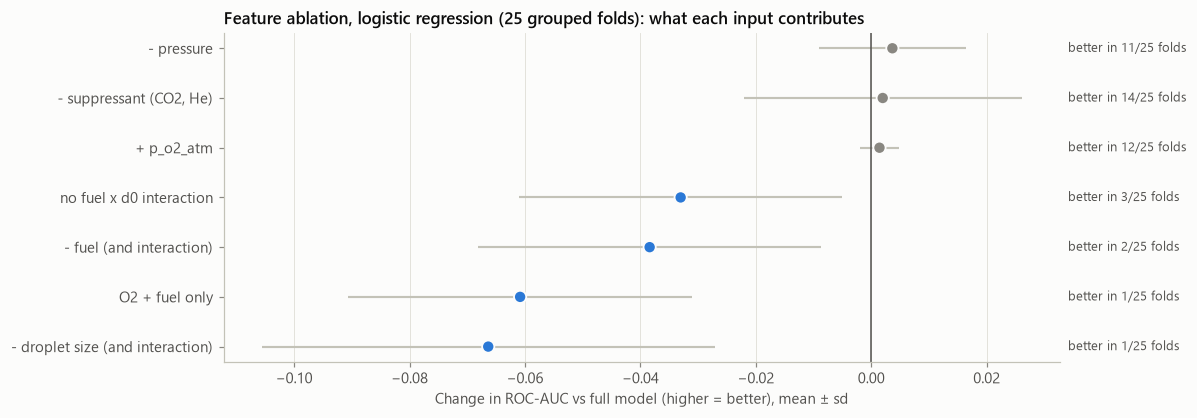

In [3]:
ab = pd.read_csv(R / "ablation.csv", index_col=0)
display(ab[["roc_auc_mean", "pr_auc_mean", "brier_mean", "log_loss_mean"]].round(3))
paired = pd.read_csv(R / "ablation_paired.csv")
fig = plots.plot_ablation(paired, "roc_auc", "ROC-AUC")
_ = eda.save(fig, "10_ablation")

**Read-out** (paired over 25 folds; "better in k/25" counts folds where the reduced model wins):
- **Droplet size is the most valuable input after O₂** (−0.066 ROC-AUC without it; better in 1/25). **Fuel**
  (−0.038) and the **fuel × droplet-size term** (−0.033, better in 3/25) also matter — confirming the EDA finding that
  droplet size acts in opposite directions for the two fuels.
- **Pressure and suppressant amount add no measurable skill** once O₂ is known (changes ≤ 0.004, better in 11–14/25).
  For the suppressants this is the O₂–suppressant coupling from the EDA: within each test series the suppressant
  fraction is almost a function of O₂, so it carries little extra information. **The model therefore cannot isolate a
  separate suppressant effect** — the dashboard must not present "adding X% CO₂ lowers risk by Y" as a model finding.
- Adding O₂ partial pressure does not help (+0.001).

## 3. Sensitivity to dataset choices

In [4]:
sens = pd.read_csv(R / "sensitivity_metrics.csv")
display(sens[["variant", "model", "tests", "sustained", "roc_auc_mean", "pr_auc_mean", "brier_mean",
              "recall@safe_mean", "precision@safe_mean"]].round(3))
pd.read_csv(R / "sensitivity_coefficients.csv", index_col=0).round(3)

,variant,model,tests,sustained,roc_auc_mean,pr_auc_mean,brier_mean,recall@safe_mean,precision@safe_mean
0,primary,logreg,252,80,0.922,0.868,0.109,0.898,0.637
1,primary,xgboost,252,80,0.886,0.802,0.136,0.875,0.578
2,primary,o2_only_logreg,252,80,0.821,0.699,0.152,0.896,0.455
3,exclude_disruption,logreg,199,27,0.904,0.727,0.075,0.869,0.287
4,exclude_disruption,xgboost,199,27,0.841,0.600,0.091,0.878,0.227
5,exclude_disruption,o2_only_logreg,199,27,0.668,0.319,0.108,0.861,0.156
6,impute_d0,logreg,264,86,0.923,0.875,0.108,0.895,0.617
7,impute_d0,xgboost,264,86,0.881,0.804,0.137,0.896,0.573
8,impute_d0,o2_only_logreg,264,86,0.820,0.709,0.149,0.881,0.470
9,exclude_anomalies,logreg,250,80,0.917,0.857,0.108,0.866,0.636


,exclude_anomalies,exclude_disruption,impute_d0,primary
feature,,,,
d0_mm,0.316,0.631,0.327,0.313
heptane_x_d0,-1.445,-1.715,-1.478,-1.503
is_heptane,0.647,0.845,0.669,0.629
missingindicator_d0_mm,NaN,NaN,0.332,NaN
pressure_atm,-0.322,-0.222,-0.276,-0.323
x_co2,-0.743,-0.477,-0.681,-0.741
x_he,-0.805,-0.626,-0.713,-0.803
x_o2,2.152,1.333,2.252,2.149


**Read-out.**
- The model ranking (logistic regression > XGBoost > O₂-only) holds in every variant.
- **Imputing the 12 missing droplet sizes** or **removing the two anomalous tests (70, 73)** changes nothing material
  (ROC-AUC 0.917–0.923).
- **Excluding Disruption** (199 tests, only 27 sustained) keeps logistic regression at ROC-AUC 0.904, but O₂ alone
  collapses to 0.668: disruptions occur mostly at high O₂, so without them "sustained" means *burned to completion*,
  which depends far more on fuel and droplet size. PR-AUC and precision drop because positives are rare (14%).
- Standardised logistic coefficients keep the **same sign in all four variants**; O₂ is always the largest effect
  and the fuel × size term always strongly negative (larger heptane droplets less likely to sustain).
  (Coefficients describe associations in this design, not causal effects.)

## 4. Stress tests — conditions absent from training (original design)

,split,model,test_tests,test_sustained,roc_auc,brier,recall@safe,precision@safe,mean_predicted,observed_rate
0,leave_out_CO2,o2_only_logreg,111,31,0.839,0.152,1.000,0.320,0.335,0.279
1,leave_out_CO2,logreg,111,31,0.879,0.146,0.968,0.357,0.425,0.279
2,leave_out_CO2,random_forest,111,31,0.850,0.163,0.968,0.330,0.422,0.279
3,leave_out_CO2,xgboost,111,31,0.845,0.185,0.935,0.372,0.445,0.279
4,leave_out_He,o2_only_logreg,47,9,0.623,0.156,0.444,0.211,0.241,0.191
5,leave_out_He,logreg,47,9,0.868,0.167,1.000,0.300,0.406,0.191
6,leave_out_He,random_forest,47,9,0.789,0.157,0.889,0.276,0.335,0.191
7,leave_out_He,xgboost,47,9,0.757,0.196,0.889,0.320,0.341,0.191
8,train_1atm_test_0.7atm,o2_only_logreg,101,38,0.891,0.141,0.974,0.430,0.482,0.376
9,train_1atm_test_0.7atm,logreg,101,38,0.905,0.296,0.342,1.000,0.052,0.376


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


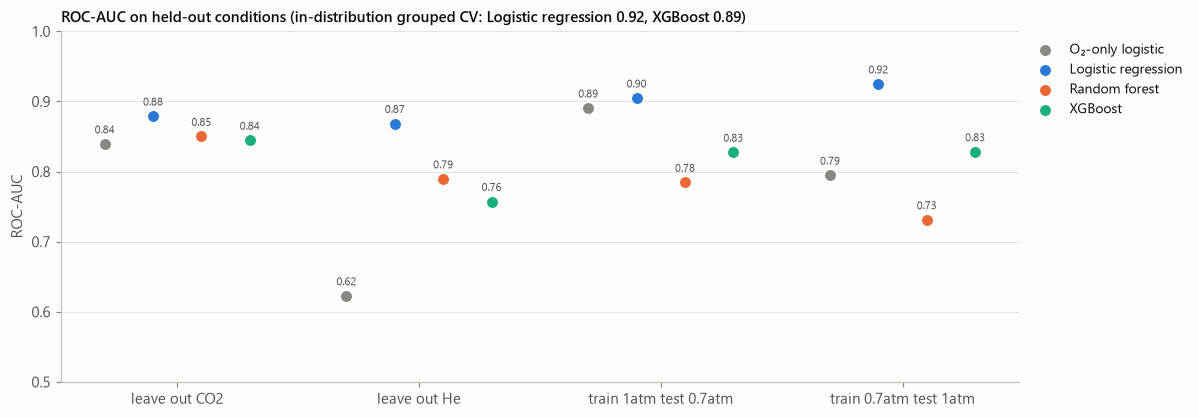

In [5]:
stress = pd.read_csv(R / "stress_metrics.csv")
display(stress[["split", "model", "test_tests", "test_sustained", "roc_auc", "brier", "recall@safe",
                "precision@safe", "mean_predicted", "observed_rate"]].round(3))
ref = pd.read_csv(ROOT / "reports" / "phase7" / "fold_metrics.csv").groupby("model")["roc_auc"].mean()
fig = plots.plot_stress(stress, {m: ref[m] for m in ["logreg", "xgboost"]})
_ = eda.save(fig, "11_stress_tests")

**Read-out.**
- **Held-out suppressant.** With no helium (or no CO₂) in training, logistic regression still ranks the held-out
  tests well (ROC-AUC 0.87–0.88) but **over-predicts** their risk (mean predicted 0.41 vs observed 0.19 for He).
  In this data, atmospheres with an untested suppressant burned less often than the model expected — an error on
  the safe side, but a reminder that predictions for an untested suppressant are not calibrated.
- **Pressure transfer exposed a real failure.** Trained on one pressure level, logistic regression ranks the other
  level well (ROC-AUC 0.905 / 0.925) but its probabilities collapse: mean predicted 0.05 vs observed 0.38, or 1.00
  vs 0.28. Diagnosis below.

In [6]:
pd.read_csv(R / "stress_no_pressure.csv").round(3)

,split,model,train_pressure_sd,roc_auc,brier,log_loss,recall@safe,precision@safe,mean_predicted,observed_rate
0,leave_out_CO2,logreg,0.141,0.879,0.146,0.441,0.968,0.357,0.425,0.279
1,leave_out_CO2,logreg_no_pressure,0.141,0.892,0.120,0.376,0.968,0.423,0.361,0.279
2,leave_out_He,logreg,0.146,0.868,0.167,0.492,1.000,0.300,0.406,0.191
3,leave_out_He,logreg_no_pressure,0.146,0.902,0.129,0.395,1.000,0.333,0.348,0.191
4,train_1atm_test_0.7atm,logreg,0.006,0.905,0.296,1.312,0.342,1.000,0.052,0.376
5,train_1atm_test_0.7atm,logreg_no_pressure,0.006,0.900,0.121,0.372,0.895,0.596,0.305,0.376
6,train_0.7atm_test_1atm,logreg,0.005,0.925,0.722,9.973,1.000,0.278,1.000,0.278
7,train_0.7atm_test_1atm,logreg_no_pressure,0.005,0.925,0.108,0.355,0.976,0.482,0.370,0.278


Inside one FLEX pressure level, pressure varies only by measurement noise (training sd ≈ 0.005 atm). After
scaling, the other level sits ~50 standard deviations away and the linear term explodes. Without pressure, the same
splits give Brier 0.11–0.12 and recall at the safe threshold 0.90–0.98. Together with section 2 (pressure adds
nothing in-distribution) this led to **decision D-001: drop pressure from the final model**; pressure still defines
the model's scope (0.7–1 atm only).

## 5. Final model selection (pressure-free candidates, same rule)

In [7]:
final_sel = pd.read_csv(R / "final_selection.csv")
display(final_sel[cols].round(4))
pd.read_csv(R / "final_fold_metrics.csv").groupby("model")["best_params"].value_counts().rename("outer folds").to_frame().head(8)

,model,log_loss_mean,log_loss_se,brier_mean,roc_auc_mean,pr_auc_mean,recall@safe,precision@safe,within_1se_of_best,selected
0,logreg_np,0.3357,0.0217,0.1033,0.9252,0.8768,0.8998,0.6254,True,True
1,logreg_np_tuned,0.3628,0.0263,0.1069,0.9235,0.8714,0.8992,0.6200,False,False
2,xgboost_np,0.3896,0.0206,0.1265,0.9043,0.8423,0.8927,0.6105,False,False
3,random_forest_np,0.3996,0.0154,0.1306,0.8955,0.8231,0.8987,0.5940,False,False
4,xgboost_np_tuned,0.4010,0.0229,0.1301,0.9000,0.8280,0.8866,0.6056,False,False
5,random_forest_np_tuned,0.4134,0.0168,0.1355,0.8908,0.8159,0.8825,0.5779,False,False


outer folds
model                  best_params                                                    
logreg_np_tuned        {"model__C": 0.3}                                            14
                       {"model__C": 1.0}                                             6
                       {"model__C": 3.0}                                             4
                       {"model__C": 10.0}                                            1
random_forest_np_tuned {"model__max_features": "sqrt", "model__min_sam...           17
                       {"model__max_features": "sqrt", "model__min_sam...            7
                       {"model__max_features": "sqrt", "model__min_sam...            1
xgboost_np_tuned       {"model__learning_rate": 0.1, "model__max_depth...            5

**Selected: `logreg_np`** — L2 logistic regression (C = 1), inputs `is_heptane`, `x_o2`, `x_co2`, `x_he`,
`d0_mm` and the fuel × droplet-size term, no tuning. It has the lowest log loss of all candidates and is also the
simplest, so the one-standard-error rule needs no tie-break.

| Metric (25 grouped folds, mean) | logreg with pressure (Phase 7) | **Final: logreg without pressure** |
|---|---|---|
| Log loss | 0.346 ± 0.023 (SE) | **0.336 ± 0.022** |
| Brier | 0.109 | **0.103** |
| ROC-AUC | 0.922 | **0.925** |
| PR-AUC | 0.868 | **0.877** |
| Recall / precision at safe threshold | 0.898 / 0.637 | 0.900 / 0.625 |

Dropping pressure also improved every tree model (XGBoost ROC-AUC 0.886 → 0.904), consistent with pressure being
noise inside each level.

## Phase 8 summary
1. Tuning does not improve on fixed, sensible hyperparameters at this data size.
2. O₂, droplet size, fuel and the fuel × size interaction carry the predictive signal; pressure and suppressant
   amount add none measurable — the model cannot separate a suppressant effect from the O₂ reduction it came with.
3. Results are stable to imputation, anomalous-test removal and (for ranking) to excluding disruptions.
4. Out-of-domain predictions can be badly miscalibrated even when ranking is fine → the dashboard must enforce the
   applicability domain.
5. Final model: pressure-free logistic regression, log loss 0.336, ROC-AUC 0.925 (cross-validated).

Next (Phase 9): calibration check of the final model's probabilities, Fire Risk bands from the validated threshold,
and the final fit saved for SHAP and the dashboard.